In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
from environment_macro import MacroTradingEnv
from stable_baselines3 import PPO

start = "2014-01-01"
end = "2022-12-31"
curr_date = "2025-10-01"
tickers = ["XOM", "CVX", "SHEL", "BP"]

In [14]:
vix = yf.download("^VIX", start=start, end=end)
print(vix.head())



/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/1013922044.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Price       Close   High    Low   Open Volume
Ticker       ^VIX   ^VIX   ^VIX   ^VIX   ^VIX
Date                                         
2014-01-02  14.23  14.59  14.00  14.32      0
2014-01-03  13.76  14.22  13.57  14.06      0
2014-01-06  13.55  14.00  13.22  13.41      0
2014-01-07  12.92  13.28  12.16  12.38      0
2014-01-08  12.87  13.24  12.86  13.04      0


In [15]:
from joblib import load

sp500 = yf.download('^GSPC', start=start, end=curr_date)
dowjones = yf.download('^DJI', start=start, end=curr_date)
nasdaq = yf.download('^IXIC', start=start, end=curr_date)

sp500_w = sp500["Close"].resample('W-FRI').last()
dowjones_w = dowjones["Close"].resample('W-FRI').last()
nasdaq_w = nasdaq["Close"].resample('W-FRI').last()

sp500_wr = sp500_w.pct_change().dropna()
dowjones_wr = dowjones_w.pct_change().dropna()
nasdaq_wr = nasdaq_w.pct_change().dropna()

sp500_wr.rename(columns={"^GSPC": "SP500 Returns"}, inplace=True)
dowjones_wr.rename(columns={"^DJI": "Dow Jones Returns"}, inplace=True)
nasdaq_wr.rename(columns={"^IXIC": "Nasdaq Returns"}, inplace=True)

sp500_wr["^GSPC"] = sp500_w["^GSPC"]
dowjones_wr["^DJI"] = dowjones_w["^DJI"]
nasdaq_wr["^IXIC"] = nasdaq_w["^IXIC"]

print(sp500_wr.head())
print(dowjones_wr.head())

sp500['Log Return'] = np.log(sp500['Close'] / sp500['Close'].shift(1))
sp500['Daily Volatility'] = sp500['Log Return'].abs()
sp500['30D Volatility'] = sp500['Log Return'].rolling(window=30).std()
sp500['60D Volatility'] = sp500['Log Return'].rolling(window=60).std()
sp500 = sp500.dropna()

dowjones['Log Return'] = np.log(dowjones['Close'] / dowjones['Close'].shift(1))
dowjones['Daily Volatility'] = dowjones['Log Return'].abs()
dowjones['30D Volatility'] = dowjones['Log Return'].rolling(window=30).std()
dowjones['60D Volatility'] = dowjones['Log Return'].rolling(window=60).std()
dowjones = dowjones.dropna()

nasdaq['Log Return'] = np.log(nasdaq['Close'] / nasdaq['Close'].shift(1))
nasdaq['Daily Volatility'] = nasdaq['Log Return'].abs()
nasdaq['30D Volatility'] = nasdaq['Log Return'].rolling(window=30).std()
nasdaq['60D Volatility'] = nasdaq['Log Return'].rolling(window=60).std()
nasdaq = nasdaq.dropna()

sp500_wvm = sp500['Daily Volatility'].resample('W-FRI').mean()
sp500_wv30 = sp500['30D Volatility'].resample('W-FRI').last()  # Rolling vol is already cumulative, so take last
sp500_wv60 = sp500['60D Volatility'].resample('W-FRI').last()

dowjones_wvm = dowjones['Daily Volatility'].resample('W-FRI').mean()
dowjones_wv30 = dowjones['30D Volatility'].resample('W-FRI').last()  # Rolling vol is already cumulative, so take last
dowjones_wv60 = dowjones['60D Volatility'].resample('W-FRI').last()

nasdaq_wvm = nasdaq['Daily Volatility'].resample('W-FRI').mean()
nasdaq_wv30 = nasdaq['30D Volatility'].resample('W-FRI').last()  # Rolling vol is already cumulative, so take last
nasdaq_wv60 = nasdaq['60D Volatility'].resample('W-FRI').last()

print(sp500_wr["SP500 Returns"].head())
sp500_wr["SP500 Rolling Returns"] = sp500_wr["SP500 Returns"].rolling(window=4).mean()
dowjones_wr["Dow Jones Rolling Returns"] = dowjones_wr["Dow Jones Returns"].rolling(window=4).mean()
nasdaq_wr["Nasdaq Rolling Returns"] = nasdaq_wr["Nasdaq Returns"].rolling(window=4).mean()
sp500_wr = sp500_wr.dropna()
dowjones_wr = dowjones_wr.dropna()
nasdaq_wr = nasdaq_wr.dropna()

sp500_wvdf = pd.DataFrame({
    'sp500_wvm': sp500_wvm,
    'sp500_wv30': sp500_wv30,
    'sp500_wv60': sp500_wv60
})

dowjones_wvdf = pd.DataFrame({
    'dowjones_wvm': dowjones_wvm,
    'dowjones_wv30': dowjones_wv30,
    'dowjones_wv60': dowjones_wv60
})

nasdaq_wvdf = pd.DataFrame({
    'nasdaq_wvm': nasdaq_wvm,
    'nasdaq_wv30': nasdaq_wv30,
    'nasdaq_wv60': nasdaq_wv60
})
print(sp500_wvdf.head())

sp500_df = sp500_wr.merge(sp500_wvdf, left_index=True, right_index=True, how='right')
dowjones_df = dowjones_wr.merge(dowjones_wvdf, left_index=True, right_index=True, how='right')
nasdaq_df = nasdaq_wr.merge(nasdaq_wvdf, left_index=True, right_index=True, how='right')

print(sp500_df.head())
print(dowjones_df.head())
print(nasdaq_df.head())

data = pd.concat([sp500_df, dowjones_df, nasdaq_df], axis=1)
data = data.dropna()
print(data.head())

hmm_model = load("binary_hmm_model.joblib")

feature_cols = [
    "SP500 Returns", "sp500_wvm", "sp500_wv30", "sp500_wv60",
    "Dow Jones Returns", "dowjones_wvm", "dowjones_wv30", "dowjones_wv60",
    "Nasdaq Returns", "nasdaq_wvm", "nasdaq_wv30", "nasdaq_wv60",
    "SP500 Rolling Returns", "Dow Jones Rolling Returns", "Nasdaq Rolling Returns"
]

# Extract features as matrix (n_samples x n_features)
X = data[feature_cols].values

# Predict regimes for all samples
regimes = hmm_model.predict(X)

# Add to DataFrame
data["Regime"] = regimes
data["Regime"] = data["Regime"].astype(int)

print(data["Regime"].value_counts())



/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/2070811032.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start=start, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/2070811032.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dowjones = yf.download('^DJI', start=start, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/2070811032.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq = yf.download('^IXIC', start=start, end=curr_date)
[*********************100%***********************]  1 of 1 completed

Ticker      SP500 Returns        ^GSPC
Date                                  
2014-01-10       0.006006  1842.369995
2014-01-17      -0.001992  1838.699951
2014-01-24      -0.026328  1790.290039
2014-01-31      -0.004301  1782.589966
2014-02-07       0.008095  1797.020020
Ticker      Dow Jones Returns          ^DJI
Date                                       
2014-01-10          -0.002000  16437.050781
2014-01-17           0.001309  16458.560547
2014-01-24          -0.035207  15879.110352
2014-01-31          -0.011352  15698.849609
2014-02-07           0.006066  15794.080078
Date
2014-01-10    0.006006
2014-01-17   -0.001992
2014-01-24   -0.026328
2014-01-31   -0.004301
2014-02-07    0.008095
Freq: W-FRI, Name: SP500 Returns, dtype: float64
            sp500_wvm  sp500_wv30  sp500_wv60
Date                                         
2014-04-04   0.006300    0.006291    0.007737
2014-04-11   0.011210    0.007988    0.008241
2014-04-18   0.006679    0.007886    0.008446
2014-04-25   0.00398

In [16]:
indexex = ["^VIX", "^IRX", "^TNX", "^TYX"]
def create_macro_df(indexes, start=start, end=curr_date):
    macro_data = {}
    for index in indexes:
        df = yf.download(index, start=start, end=curr_date)
        df.columns = df.columns.get_level_values(0)
        print(df.head())
        df.drop(columns=["Volume"], inplace=True)
        macro_data[index] = df
    macro_df = pd.concat(macro_data.values(), axis=1)
    macro_df = macro_df.ffill()
    return macro_df 

macro_data = create_macro_df(indexex, start=start, end=curr_date)
print(type(macro_data.index))
macro_data = macro_data.merge(data["Regime"], left_index=True, right_index=True, how='left')
macro_data["Regime"] = macro_data["Regime"].ffill()
macro_data = macro_data.dropna()
macro_data["Regime"] = macro_data["Regime"].astype(int)
print(macro_data.head())

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/2533221495.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(index, start=start, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/2533221495.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(index, start=start, end=curr_date)


Price       Close   High    Low   Open  Volume
Date                                          
2014-01-02  14.23  14.59  14.00  14.32       0
2014-01-03  13.76  14.22  13.57  14.06       0
2014-01-06  13.55  14.00  13.22  13.41       0
2014-01-07  12.92  13.28  12.16  12.38       0
2014-01-08  12.87  13.24  12.86  13.04       0


[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/2533221495.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(index, start=start, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/2533221495.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(index, start=start, end=curr_date)
[*********************100%***********************]  1 of 1 completed

Price       Close   High    Low   Open  Volume
Date                                          
2014-01-02  0.058  0.060  0.055  0.060       0
2014-01-03  0.058  0.060  0.058  0.060       0
2014-01-06  0.045  0.055  0.045  0.055       0
2014-01-07  0.043  0.048  0.040  0.048       0
2014-01-08  0.040  0.043  0.035  0.037       0
Price       Close   High    Low   Open  Volume
Date                                          
2014-01-02  2.985  3.034  2.978  3.028       0
2014-01-03  2.995  3.012  2.971  2.998       0
2014-01-06  2.961  2.984  2.946  2.976       0
2014-01-07  2.937  2.965  2.937  2.956       0
2014-01-08  2.993  3.010  2.976  2.984       0
Price       Close   High    Low   Open  Volume
Date                                          
2014-01-02  3.919  3.967  3.910  3.963       0
2014-01-03  3.930  3.951  3.908  3.941       0
2014-01-06  3.898  3.915  3.879  3.907       0
2014-01-07  3.881  3.906  3.880  3.899       0
2014-01-08  3.903  3.932  3.901  3.912       0
<class 'panda

In [17]:
start_data = "2014-04-04"

def download_data(tickers, start=start_data, end=end):
    data_dict = {}
    for ticker in tickers:
        df = yf.download(ticker, start=start, end=end)
        df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
        data_dict[ticker] = df
    return data_dict

# ETF tickers = ["TIP", "SHY", "IEF", "TLT", "AGG", "EEM", "EFA", "SPY", "QQQ", "DIA"]
data_dict = download_data(tickers)

for key, df in data_dict.items():
    print(f"{key}")
    print(df.head())
    print(df.shape[0])
    print(df.isna().any(axis=1).sum())

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/845254581.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/845254581.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/845254581.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/845254581.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.

XOM
Price            Open       High        Low      Close    Volume
Ticker            XOM        XOM        XOM        XOM       XOM
Date                                                            
2014-04-04  60.586374  60.839072  59.957703  60.007011  12496100
2014-04-07  59.939198  60.111773  59.631028  59.649517  10120700
2014-04-08  59.791286  60.327500  59.631036  60.062473  10243000
2014-04-09  60.247365  60.272019  59.557061  59.988503  10463900
2014-04-10  59.772788  60.265858  59.316692  59.649517  13443400
2202
0
CVX
Price            Open       High        Low      Close   Volume
Ticker            CVX        CVX        CVX        CVX      CVX
Date                                                           
2014-04-04  73.562742  73.562742  72.850149  72.979156  5301300
2014-04-07  72.684286  72.991438  72.082268  72.082268  5241300
2014-04-08  72.278843  72.678136  71.983976  72.364845  4706100
2014-04-09  72.383290  73.255598  72.235854  73.163452  5376500
2014-04-10  71.99

In [18]:
from stable_baselines3.common.env_util import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

macro_data_t = macro_data.loc[start_data:end]
def make_env():
    env = MacroTradingEnv(data_dict, macro_data_t, initial_balance=10000, lookback_window=30, max_position_per_asset=0.75, buy_fraction=0.2, sell_fraction=0.5)
    return Monitor(env)

env = DummyVecEnv([make_env])  # Stable-Baselines3 expects vectorized envs
base_env = env.envs[0]

In [19]:
model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    ent_coef=0.01,  # entropy bonus to encourage exploration
    tensorboard_log="./ppo_trading_tensorboard/"
)

model.learn(total_timesteps=100_000)

Using cpu device
Logging to ./ppo_trading_tensorboard/PPO_49
-----------------------------
| time/              |      |
|    fps             | 285  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.17e+03    |
|    ep_rew_mean          | 0.548       |
| time/                   |             |
|    fps                  | 282         |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010245808 |
|    clip_fraction        | 0.104       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.39       |
|    explained_variance   | -3.26       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0463     |
|    n_updates 

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/4099690995.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2014-04-04", end="2023-12-31")
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/4099690995.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start_data, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/4099690995.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start_data, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/4099690995.py:62: FutureWarning: YF.download() has changed

Initial Portfolio Value: $10,000.00
Final Portfolio Value: $21,861.37
Total Return: 118.61%
Max Portfolio Value: $22,777.20
Max Drawdown: 52.86%


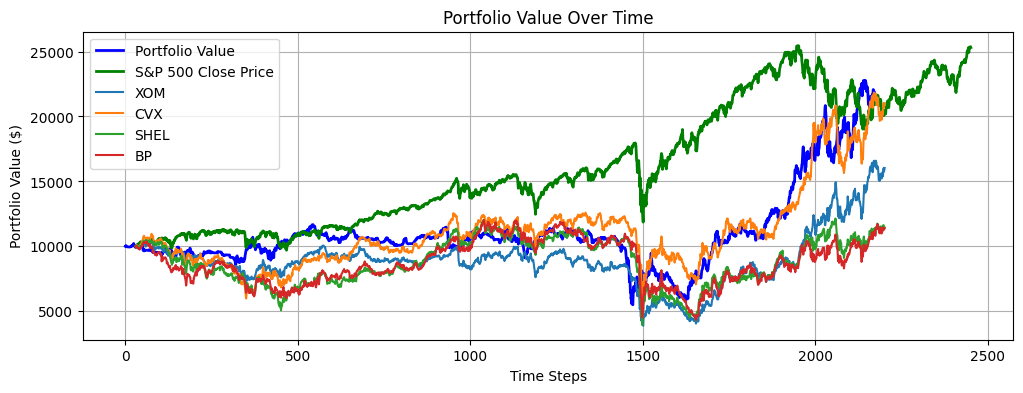

In [20]:
import matplotlib.pyplot as plt

def evaluate_policy(env, model, episodes=1):
    """Simple policy evaluation with key metrics and plots"""
    
    # Run episode
    obs, info = env.reset()
    portfolio_values = [info['portfolio_value']]
    actions_taken = []
    
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        
        portfolio_values.append(info['portfolio_value'])
        actions_taken.append(action)
        
        if terminated or truncated:
            break
    
    # Calculate metrics
    initial_value = portfolio_values[0]
    final_value = portfolio_values[-1]
    total_return = (final_value - initial_value) / initial_value * 100
    max_value = max(portfolio_values)

    sp500 = yf.download("^GSPC", start="2014-04-04", end="2023-12-31")
    sp500_reset = sp500.reset_index()
    sp500_aligned = sp500_reset[30:]
    sp500_Close = sp500_aligned['Close'].dropna()

    # Normalize SP500 to start at $10,000
    normalized_sp500 = sp500_Close / sp500_Close.iloc[0] * 10000

    def max_drawdown(portfolio):
        """Calculate the maximum drawdown of a portfolio."""
        peak = portfolio[0]
        max_dd = 0
        for value in portfolio:
            if value > peak:
                peak = value
            dd = (peak - value) / peak
            if dd > max_dd:
                max_dd = dd
        return max_dd
    
    max_dd = max_drawdown(portfolio_values)
    
    # Print results
    print(f"Initial Portfolio Value: ${initial_value:,.2f}")
    print(f"Final Portfolio Value: ${final_value:,.2f}")
    print(f"Total Return: {total_return:.2f}%")
    print(f"Max Portfolio Value: ${max_value:,.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    
    # Plot portfolio value
    plt.figure(figsize=(12, 4))
    plt.plot(portfolio_values, linewidth=2, color="blue", label="Portfolio Value")
    plt.plot(normalized_sp500, linewidth=2, color="green", label="S&P 500 Close Price")

    for tick in tickers:
        tick_data = yf.download(tick, start=start_data, end=end)
        tick_data_reset = tick_data.reset_index()
        tick_data_aligned = tick_data_reset[30:]
        tick_data_close = tick_data_aligned['Close'].dropna()

        # Normalize SP500 to start at $10,000
        normalized_tick_data = tick_data_close / tick_data_close.iloc[0] * 10000
        plt.plot(normalized_tick_data, label=tick)

    plt.title('Portfolio Value Over Time')
    plt.xlabel('Time Steps')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return {
        'portfolio_values': portfolio_values,
        'total_return': total_return,
        'final_value': final_value
    }

# Usage in your notebook:
results = evaluate_policy(base_env, model)

In [21]:
obs = env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _ = env.step(action)
    env.envs[0].render()

Step: 1
Portfolio Value: $9,978.66
Cash: $6,400.00
XOM: 0.0000 shares @ $62.47
CVX: 26.2559 shares @ $75.89
SHEL: 0.0000 shares @ $44.26
BP: 60.2867 shares @ $26.31
--------------------------------------------------
Step: 2
Portfolio Value: $10,051.72
Cash: $4,096.00
XOM: 0.0000 shares @ $63.31
CVX: 43.1215 shares @ $76.92
SHEL: 0.0000 shares @ $44.50
BP: 99.2112 shares @ $26.60
--------------------------------------------------
Step: 3
Portfolio Value: $10,017.42
Cash: $2,621.44
XOM: 0.0000 shares @ $62.98
CVX: 53.7711 shares @ $76.59
SHEL: 0.0000 shares @ $44.69
BP: 123.8518 shares @ $26.46
--------------------------------------------------
Step: 4
Portfolio Value: $9,999.72
Cash: $1,677.72
XOM: 0.0000 shares @ $62.87
CVX: 60.6161 shares @ $76.43
SHEL: 0.0000 shares @ $44.43
BP: 139.7019 shares @ $26.41
--------------------------------------------------
Step: 5
Portfolio Value: $9,963.93
Cash: $3,186.63
XOM: 0.0000 shares @ $62.90
CVX: 65.0061 shares @ $76.11
SHEL: 0.0000 shares @ $4

In [22]:
forward_data_dict = download_data(tickers, start=end, end=curr_date)
macro_data_f = macro_data.loc[end:curr_date]
forward_env = MacroTradingEnv(
    data=forward_data_dict,
    macro_data=macro_data_f,
    initial_balance=10000,
    lookback_window=30,
    normalize_observations=True,
    max_position_per_asset=0.75,
    buy_fraction=0.2,
    sell_fraction=0.5
)

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/845254581.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/845254581.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/845254581.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/845254581.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/3761606971.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/3761606971.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/3761606971.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_80959/3761606971.py:25: FutureWarning: YF.download() has changed argument aut

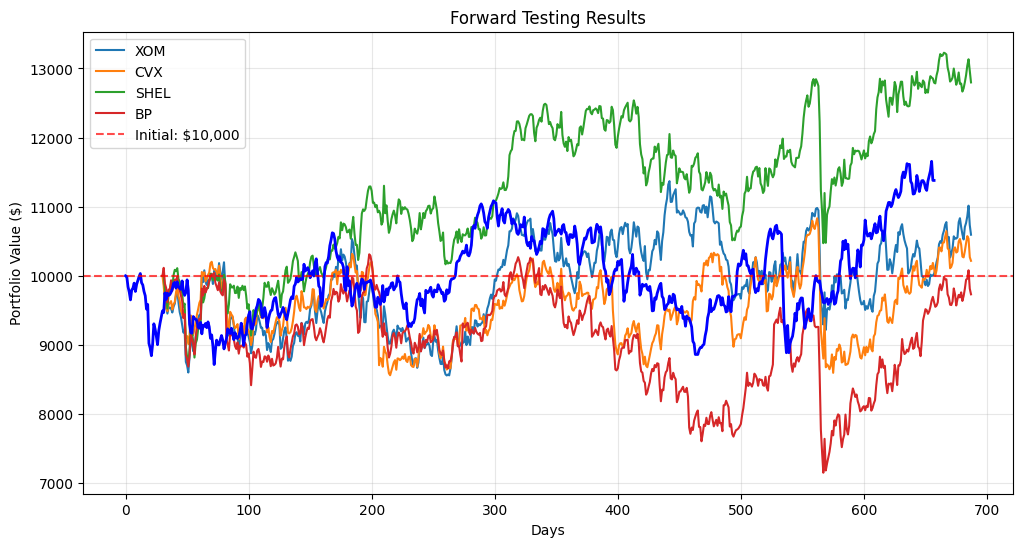

Initial Portfolio Value: $10,000.00
Final Portfolio Value: $11,379.42
Total Return: 13.79%


{'initial_value': 10000,
 'final_value': 11379.42391790028,
 'total_return': 13.794239179002798,
 'portfolio_values': [10000,
  9989.58284917312,
  9841.101266197387,
  9765.186176293424,
  9651.97441610103,
  9794.732710365555,
  9821.52355648537,
  9894.256083531021,
  9773.882280252064,
  9875.34467237541,
  9932.531542972843,
  9989.20025596856,
  10033.37410724839,
  9900.193710131447,
  9867.540570566838,
  9774.256111703866,
  9711.51690781702,
  9518.944117149667,
  9585.940535886186,
  9022.985628286075,
  8955.507729671266,
  8844.319316847115,
  9010.345997675522,
  9306.03723139252,
  9231.954280771213,
  9129.571441731721,
  9004.029096589336,
  9207.668276281474,
  9312.433647179412,
  9403.368632564901,
  9492.6273447899,
  9469.055119259312,
  9753.383110588478,
  9659.467117841252,
  9748.852801422156,
  9716.01201689929,
  9729.321671942043,
  9761.73221290906,
  9812.17620382863,
  9890.10416286866,
  9904.7471776217,
  9821.598087633374,
  9913.013184756208,
  9848.

In [23]:
def simple_forward_test(model, env):
    """
    Simple forward testing - just run the model and get basic results
    """
    # Reset environment
    obs, info = env.reset()
    
    portfolio_values = [info['portfolio_value']]
    
    # Run through all steps
    done = False
    while not done:
        # Get action from model
        action, _ = model.predict(obs, deterministic=True)
        
        # Take step
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Store portfolio value
        portfolio_values.append(info['portfolio_value'])

    plt.figure(figsize=(12, 6))
    for tick in tickers:
        tick_data = yf.download(tick, start=end, end=curr_date)
        tick_data_reset = tick_data.reset_index()
        tick_data_aligned = tick_data_reset[30:]
        tick_data_close = tick_data_aligned['Close'].dropna()

        # Normalize SP500 to start at $10,000
        normalized_tick_data = tick_data_close / tick_data_close.iloc[0] * 10000
        plt.plot(normalized_tick_data, label=tick)
    
    # Calculate results
    initial_value = env.initial_balance
    final_value = portfolio_values[-1]
    total_return = ((final_value / initial_value) - 1) * 100
    
    # Plot results
    plt.plot(portfolio_values, linewidth=2, color='blue')
    plt.axhline(y=initial_value, color='red', linestyle='--', alpha=0.7, label=f'Initial: ${initial_value:,.0f}')
    plt.title('Forward Testing Results')
    plt.xlabel('Days')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Print results
    print(f"Initial Portfolio Value: ${initial_value:,.2f}")
    print(f"Final Portfolio Value: ${final_value:,.2f}")
    print(f"Total Return: {total_return:.2f}%")
    
    return {
        'initial_value': initial_value,
        'final_value': final_value,
        'total_return': total_return,
        'portfolio_values': portfolio_values
    }

simple_forward_test(model, forward_env)

In [24]:
obs, info = forward_env.reset()

# Run through all steps
done = False
while not done:
    # Get action from model
    action, _ = model.predict(obs, deterministic=True)
    
    # Take step
    obs, reward, terminated, truncated, info = forward_env.step(action)
    done = terminated or truncated
    # Render environment
    forward_env.render()

Step: 1
Portfolio Value: $9,989.58
Cash: $6,400.00
XOM: 0.0000 shares @ $106.11
CVX: 13.1585 shares @ $149.80
SHEL: 0.0000 shares @ $55.91
BP: 45.1887 shares @ $35.82
--------------------------------------------------
Step: 2
Portfolio Value: $9,841.10
Cash: $3,276.80
XOM: 0.0000 shares @ $102.03
CVX: 21.7033 shares @ $146.45
SHEL: 18.3157 shares @ $54.79
BP: 68.0614 shares @ $35.00
--------------------------------------------------
Step: 3
Portfolio Value: $9,765.19
Cash: $1,677.72
XOM: 0.0000 shares @ $101.93
CVX: 26.1782 shares @ $144.79
SHEL: 27.8850 shares @ $54.26
BP: 80.0444 shares @ $34.78
--------------------------------------------------
Step: 4
Portfolio Value: $9,651.97
Cash: $858.99
XOM: 0.0000 shares @ $100.61
CVX: 28.4957 shares @ $144.20
SHEL: 32.8326 shares @ $53.24
BP: 86.2183 shares @ $34.05
--------------------------------------------------
Step: 5
Portfolio Value: $9,794.73
Cash: $439.80
XOM: 0.0000 shares @ $101.53
CVX: 29.6870 shares @ $145.63
SHEL: 35.4139 share